In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\Export4.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2585 entries, 0 to 2584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  2585 non-null   str  
 1   Message  2585 non-null   str  
 2   Status   2585 non-null   str  
dtypes: str(3)
memory usage: 60.7 KB


In [19]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252521    1417
0x252513     717
0x252501     220
0x252511     204
0x252514      27
Name: count, dtype: int64

In [20]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2585 entries, 0 to 2584
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  2585 non-null   str  
 1   Message  2585 non-null   str  
 2   Status   2585 non-null   str  
 3   Headers  2585 non-null   str  
dtypes: str(4)
memory usage: 80.9 KB


Odometer

In [21]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 744 entries, 0 to 2555
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             744 non-null    str  
 1   Message             744 non-null    str  
 2   Status              744 non-null    str  
 3   Headers             744 non-null    str  
 4   Odometer in meters  744 non-null    int64
 5   Date                744 non-null    str  
 6   Raw data            744 non-null    str  
dtypes: int64(1), str(6)
memory usage: 46.5 KB
None


260726000041 -> 0 -> 1893541.0 -> 0x252513005918E40869487060207049003C38402D000000294E0000000700644100000000000000FFFFFFFFFFFF00D5001CE4A50026072600004100003C42032693C22A421841061000A203912682FFFFFF0000210000FFFFFF
260726000142 -> 1 -> 1894625.0 -> 0x252513005918E50869487060207049003C38402D000000304E0000000700644100000000000000FFFFFFFFFFFF00D5001CE8E100260726000142CDCC34429E2493C2D61B1841065000A303912747FFFFFF0000210000FFFFFF
260726000242 -> 2 -> 1895693.0 -> 0x252513005918E60869487060207049003C38402D000000414C0000000700644100000000000000FFFFFFFFFFFF00D5001CED0D0026072600024266663E423C2393C211F61741063000A203912747FFFFFF0000210000FFFFFF
260726000342 -> 3 -> 1896563.0 -> 0x252513005918E70869487060207049003C38402D000000334D0000000700644100000000000000FFFFFFFFFFFF00D5001CF0730026072600034200003C421E2293C24AD717410230009D03912757FFFFFF0000220000FFFFFF
260726000442 -> 4 -> 1897106.0 -> 0x252513005918E80869487060207049003C38402D0000004B4D0000000700644100000000000000FFFFFFFFFFFF00D5001CF29200

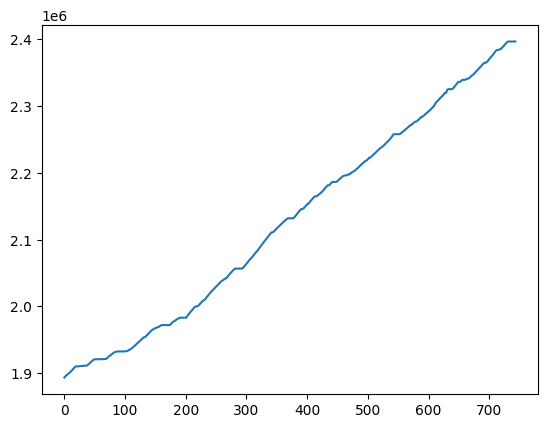

In [22]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [23]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_aux_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        speed.append(int(unit_aux.iloc[i,2][142:145]))  
        date.append(unit_aux.iloc[i,2][106:118])
        raw.append(unit_aux.iloc[i,2])   
    except:
        pass

unit_aux_speed['Speed']=speed
unit_aux_speed['Date']=date
unit_aux_speed['Raw data']=raw

unit=unit_aux_speed.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 744 entries, 0 to 716
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     744 non-null    int64
 1   Date      744 non-null    str  
 2   Raw data  744 non-null    str  
dtypes: int64(1), str(2)
memory usage: 23.2 KB
None


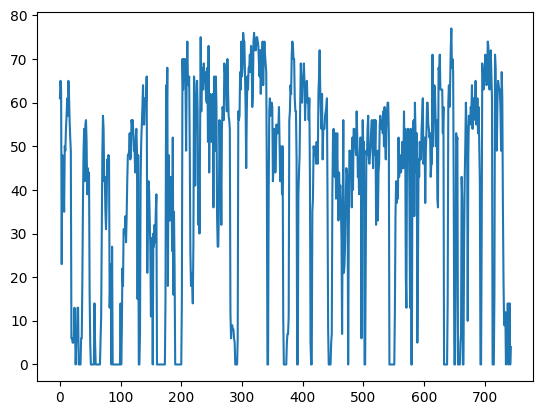

In [24]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])

plt.plot(x_axis,y_axis)

Satellites

In [25]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

for i in range(0,unit.shape[0]):
    if unit.iloc[i,5]>0:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

128 -> 2026-07-26 02:01:17.326 -> 17 -> 0x252513005919480869487060207049003C38402D00000037D10000000700644100000000000000FFFFFFFFFFFF00D5001D869C0026072602010066667442D82193C2082013410300010103912742FFFFFF00001E0000FFFFFF
128 -> 2026-07-26 02:01:17.566 -> 17 -> 0x252513005919490869487060207049003C38402D0000004BD10000000700644100000000000000FFFFFFFFFFFF00D5001D888600260726020200CDCC7242152493C2F41C13410340010E03912749FFFFFF00001E0000FFFFFF
128 -> 2026-07-26 02:23:07.710 -> 19 -> 0x2525130059195C0869487060207049003C38402D00000000D30000000700644100000000000000FFFFFFFFFFFF00D5001DC3FC00260726022100CDCC7442214C93C202A21141049000AB03912701FFFFFF00001E0000FFFFFF
128 -> 2026-07-26 02:23:09.771 -> 19 -> 0x2525130059195D0869487060207049003C38402D00000000D30000000700644100000000000000FFFFFFFFFFFF00D5001DC66D0026072602215900006442494C93C2B28B1141015000D103912689FFFFFF00001E0000FFFFFF
128 -> 2026-07-26 02:23:11.671 -> 18 -> 0x2525130059195E0869487060207049003C38402D0000000DD2000000070064410000000000

Coordinates

In [26]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
latitude=[]
longitude=[]
speed=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    latitude.append(unit_aux.iloc[i,2][135:142])
    longitude.append(unit_aux.iloc[i,2][126:134])
    speed.append(int(unit_aux.iloc[i,2][142:145],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Latitude']=latitude
unit_aux['Longitude']=longitude
unit_aux['Raw data']=raw
unit_aux['Date']=date
unit_aux['Speed']=speed

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

for i in range(0,unit.shape[0]):
    num_events=num_events+1
    print(unit.iloc[i,4],'->', unit.iloc[i,5], '->',unit.iloc[i,8],unit.iloc[i,7])

<class 'pandas.DataFrame'>
Index: 744 entries, 0 to 2555
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Created    744 non-null    str  
 1   Message    744 non-null    str  
 2   Status     744 non-null    str  
 3   Headers    744 non-null    str  
 4   Latitude   744 non-null    str  
 5   Longitude  744 non-null    str  
 6   Raw data   744 non-null    str  
 7   Date       744 non-null    str  
 8   Speed      744 non-null    int64
dtypes: int64(1), str(8)
memory usage: 58.1 KB
None
A421841 -> 032693C2 -> 97 260726000041
61B1841 -> 9E2493C2 -> 101 260726000142
1F61741 -> 3C2393C2 -> 99 260726000242
AD71741 -> 1E2293C2 -> 35 260726000342
5C41741 -> 572193C2 -> 72 260726000442
5A51741 -> 382093C2 -> 69 260726000542
2881741 -> 391F93C2 -> 65 260726000641
A731741 -> 711E93C2 -> 53 260726000742
A571741 -> 691D93C2 -> 80 260726000842
43A1741 -> 5D1C93C2 -> 73 260726000942
21A1741 -> 421B93C2 -> 84 260726001042
0F81641 -> 

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [27]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16) ))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\in_outs.csv')

<class 'pandas.DataFrame'>
Index: 744 entries, 0 to 1374
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  744 non-null    str  
 1   Message  744 non-null    str  
 2   Status   744 non-null    str  
 3   Headers  744 non-null    str  
dtypes: str(4)
memory usage: 29.1 KB


In [28]:
e0x=raw_data[raw_data['Status'].str.contains('3E0')]
row_number=e0x.shape[0]
e0x.info()
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

<class 'pandas.DataFrame'>
Index: 1431 entries, 1 to 2582
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1431 non-null   str  
 1   Message  1431 non-null   str  
 2   Status   1431 non-null   str  
 3   Headers  1431 non-null   str  
dtypes: str(4)
memory usage: 55.9 KB


In [36]:
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
date_fs02_dec_value=[]
fs01_raw_data=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E01')
    if aux>0:
        fs01=(e0x_aux[48:66])
        #print(fs01,e0x.iloc[i,2])
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs01=i
            fs01_raw_data.append(e0x_aux)
            
#print(i, raw_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E02')
    if aux>0:
        fs02=e0x_aux[48:66]
        #print(fs02,aux)
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs02=i
            fs02_raw_data.append(e0x_aux)
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
#print('El Ncode en decimal es:')
values_dates_fs01['value']=fs01_dec_value
values_dates_fs01['date']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['value']=fs02_dec_value
values_dates_fs02['date']=date_fs02_dec_value
values_dates_fs02['raw data']=fs02_raw_data

values_dates_fs01_ordered=values_dates_fs01.sort_values('date',ascending=True)
values_dates_fs02_ordered=values_dates_fs02.sort_values('date',ascending=True)

values_dates_fs01_ordered.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\macu\Export_t6a896.csv')
print("Last fuel report fs01: ",e0x.iloc[last_index_fs01,0],"Last fuel report fs02: ",e0x.iloc[last_index_fs02,0])

Last fuel report fs01:  2026-07-27 17:28:08.260 Last fuel report fs02:  Series([], Name: Created, dtype: str)


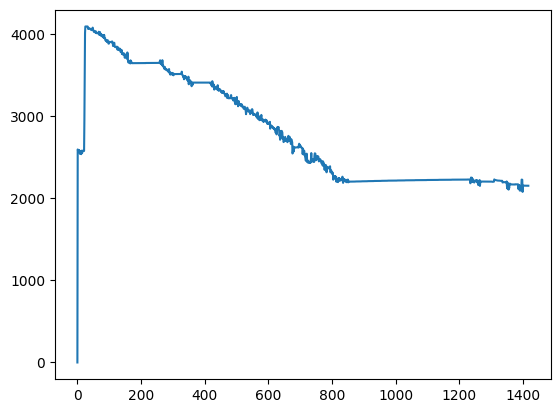

In [37]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,values_dates_fs01_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

In [38]:
for i in range(0,values_dates_fs01.shape[0]):
    if int(values_dates_fs01.iloc[i,0])>4095:
        print(values_dates_fs01.iloc[i])

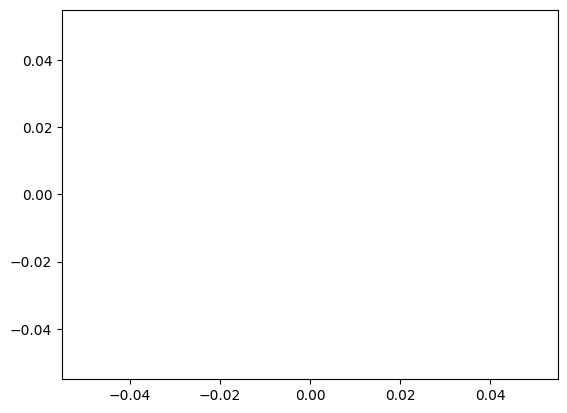

In [35]:
plt.plot(fs02_x_values,values_dates_fs02_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)